#### IMPORTING NECESSARY LIBRARIES

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings('ignore')

#### LOAD DATASET

In [5]:
matches = pd.read_csv('matches.csv')

#### DATASET PREVIEW

In [7]:
matches.head()       #view top 5 rows of dataset

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [8]:
matches.tail()       #view bottom 5 rows of data

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon


In [9]:
matches.shape

(1095, 20)

In [10]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [11]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

#### DATA CLEANING

**REMOVING UNWANTED COLUMNS**

In [14]:
matches.drop(['id','umpire1','umpire2'],axis=1,inplace=True)

**CHECKING DUPLICATES**

In [16]:
matches.duplicated().sum()

0

**CHECKING NULL VALUES**

In [18]:
matches.isna().sum()

season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
dtype: int64

In [19]:
#fixing teams name
team_replace_dict = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals'
}
cols_to_fix = ['team1', 'team2', 'toss_winner', 'winner']

for col in cols_to_fix:
    matches[col] = matches[col].replace(team_replace_dict)

In [20]:
#fixing city names
city_replace_dict = {
    'Bangalore': 'Bengaluru',
    'Dharamsala': 'Dharamshala',
    'Navi Mumbai': 'Mumbai',
    'Mohali': 'Chandigarh',
    'Visakhapatnam': 'Vizag', 
}
matches['city'] = matches['city'].replace(city_replace_dict)

In [21]:
#fixing venue names
venue_replace_dict = {
    'Feroz Shah Kotla': 'Arun Jaitley Stadium, Delhi',
    'Arun Jaitley Stadium': 'Arun Jaitley Stadium, Delhi',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium, Delhi',

    'M Chinnaswamy Stadium': 'M. Chinnaswamy Stadium, Bengaluru',
    'M.Chinnaswamy Stadium': 'M. Chinnaswamy Stadium, Bengaluru',
    'M Chinnaswamy Stadium, Bengaluru': 'M. Chinnaswamy Stadium, Bengaluru',

    'Wankhede Stadium': 'Wankhede Stadium, Mumbai',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium, Mumbai',

    'MA Chidambaram Stadium': 'MA Chidambaram Stadium, Chepauk',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium, Chepauk',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium, Chepauk',

    'Punjab Cricket Association Stadium, Mohali': 'IS Bindra Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium': 'IS Bindra Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'IS Bindra Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'IS Bindra Stadium, Mohali',

    'Dr DY Patil Sports Academy': 'Dr DY Patil Stadium, Mumbai',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Stadium, Mumbai',

    'Rajiv Gandhi International Stadium': 'Rajiv Gandhi Intl. Stadium, Hyderabad',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi Intl. Stadium, Hyderabad',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi Intl. Stadium, Hyderabad',

    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium': 'ACA-VDCA Stadium, Visakhapatnam',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'ACA-VDCA Stadium, Visakhapatnam',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Brabourne Stadium': 'Brabourne Stadium, Mumbai',
    
    'Sheikh Zayed Stadium': 'Sheikh Zayed Stadium, Abu Dhabi',
    'Zayed Cricket Stadium, Abu Dhabi': 'Sheikh Zayed Stadium, Abu Dhabi',
    
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'HPCA Stadium, Dharamsala',
    'Himachal Pradesh Cricket Association Stadium':'HPCA Stadium, Dharamsala',
    
    
    'Maharashtra Cricket Association Stadium, Pune': 'MCA Stadium, Pune',
    'Maharashtra Cricket Association Stadium':'MCA Stadium, Pune',
    
    'Eden Gardens':'Eden Gardens, Kolkata',
    'Eden Gardens, Kolkata': 'Eden Gardens, Kolkata',
    
    'Shaheed Veer Narayan Singh International Stadium, Raipur': 'SVNS International Stadium, Raipur',
    'Barsapara Cricket Stadium, Guwahati': 'Barsapara Cricket Stadium, Guwahati',
    'Vidarbha Cricket Association Stadium, Nagpur': 'VCA Stadium, Jamtha, Nagpur',
    'Green Park Stadium': 'Green Park, Kanpur'    
}
matches['venue'] = matches['venue'].replace(venue_replace_dict)

**HANDLING NULL VALUES**

In [23]:
dict = matches[matches['city'].notnull()].drop_duplicates(subset='venue').set_index('venue')['city'].to_dict()
dict

{'M. Chinnaswamy Stadium, Bengaluru': 'Bengaluru',
 'IS Bindra Stadium, Mohali': 'Chandigarh',
 'Arun Jaitley Stadium, Delhi': 'Delhi',
 'Wankhede Stadium, Mumbai': 'Mumbai',
 'Eden Gardens, Kolkata': 'Kolkata',
 'Sawai Mansingh Stadium': 'Jaipur',
 'Rajiv Gandhi Intl. Stadium, Hyderabad': 'Hyderabad',
 'MA Chidambaram Stadium, Chepauk': 'Chennai',
 'Dr DY Patil Stadium, Mumbai': 'Mumbai',
 'Newlands': 'Cape Town',
 "St George's Park": 'Port Elizabeth',
 'Kingsmead': 'Durban',
 'SuperSport Park': 'Centurion',
 'Buffalo Park': 'East London',
 'New Wanderers Stadium': 'Johannesburg',
 'De Beers Diamond Oval': 'Kimberley',
 'OUTsurance Oval': 'Bloemfontein',
 'Brabourne Stadium, Mumbai': 'Mumbai',
 'Sardar Patel Stadium, Motera': 'Ahmedabad',
 'Barabati Stadium': 'Cuttack',
 'Vidarbha Cricket Association Stadium, Jamtha': 'Nagpur',
 'HPCA Stadium, Dharamsala': 'Dharamshala',
 'Nehru Stadium': 'Kochi',
 'Holkar Cricket Stadium': 'Indore',
 'ACA-VDCA Stadium, Visakhapatnam': 'Vizag',
 'Subr

In [24]:
matches['city'] = matches['city'].fillna(matches['venue'].map(dict))

In [25]:
matches['player_of_match'].fillna('No Award', inplace=True)

In [26]:
matches['result'].unique()

array(['runs', 'wickets', 'tie', 'no result'], dtype=object)

In [27]:
matches.loc[matches['result'] == 'no result', 'winner'] = 'No winner'

In [28]:
matches['method'].unique()

array([nan, 'D/L'], dtype=object)

In [29]:
matches.loc[
    (matches['result'] == 'no result') & (matches['method'].isnull()),'method'] = 'Match Abandoned'

In [30]:
matches['method'].fillna('Normal match',inplace=True)

In [31]:
matches['target_runs'].fillna('0',inplace=True)

In [32]:
matches['result_margin'].fillna('0',inplace=True)

In [33]:
matches['target_overs'].fillna('20',inplace=True)

In [34]:
matches.isna().sum().sum()

0

**RENAMING COLUMNS**

In [36]:
matches.rename(columns={'season':'year'},inplace=True)
matches.rename(columns={'result_margin': 'win_by'}, inplace=True)

#### FEATURE ENGINEERING

In [38]:
dictionary = {
    '2007/08': 1,
    '2009': 2,
    '2009/10': 3,
    '2011': 4,
    '2012': 5,
    '2013': 6,
    '2014': 7,
    '2015': 8,
    '2016': 9,
    '2017': 10,
    '2018': 11,
    '2019': 12,
    '2020/21': 13,
    '2021': 14,
    '2022': 15,
    '2023': 16,
    '2024': 17
}
matches['season'] = matches['year'].map(dictionary)

In [39]:
matches['match_time'] = matches.duplicated(subset='date').map({False: 'Evening', True: 'Afternoon'})

In [40]:
matches['match_day'] = pd.to_datetime(matches['date']).dt.day_name()

**CHANGING DATA TYPES**

In [42]:
matches['date'] = pd.to_datetime(matches['date'])
matches['target_runs'] = matches['target_runs'].astype(int)
matches['win_by'] = matches['win_by'].astype(int)
matches['super_over'] =matches['super_over'].map({'Y': True, 'N': False})

In [43]:
matches['year']= matches['year'].replace("2007/08","2008")
matches['year'] =matches['year'].replace("2009/10","2010")
matches['year']= matches['year'].replace("2020/21","2020")
matches['year']= matches['year'].astype(int)

### EXPLORATORY DATA ANALYSIS

In [45]:
matches

,year,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,win_by,target_runs,target_overs,super_over,method,season,match_time,match_day
0,2008,Bengaluru,2008-04-18,League,BB McCullum,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20.0,False,Normal match,1,Evening,Friday
1,2008,Chandigarh,2008-04-19,League,MEK Hussey,"IS Bindra Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20.0,False,Normal match,1,Evening,Saturday
2,2008,Delhi,2008-04-19,League,MF Maharoof,"Arun Jaitley Stadium, Delhi",Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20.0,False,Normal match,1,Afternoon,Saturday
3,2008,Mumbai,2008-04-20,League,MV Boucher,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5,166,20.0,False,Normal match,1,Evening,Sunday
4,2008,Kolkata,2008-04-20,League,DJ Hussey,"Eden Gardens, Kolkata",Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20.0,False,Normal match,1,Afternoon,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi Intl. Stadium, Hyderabad",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4,215,20.0,False,Normal match,17,Evening,Sunday
1091,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8,160,20.0,False,Normal match,17,Evening,Tuesday
1092,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4,173,20.0,False,Normal match,17,Evening,Wednesday
1093,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36,176,20.0,False,Normal match,17,Evening,Friday


**City and Venue based analysis**

In [47]:
#Which Venues Belong to Which Cities 
matches[['city', 'venue']].drop_duplicates().sort_values('city')

,city,venue
398,Abu Dhabi,"Sheikh Zayed Stadium, Abu Dhabi"
120,Ahmedabad,"Sardar Patel Stadium, Motera"
836,Ahmedabad,"Narendra Modi Stadium, Ahmedabad"
0,Bengaluru,"M. Chinnaswamy Stadium, Bengaluru"
101,Bloemfontein,OUTsurance Oval
58,Cape Town,Newlands
73,Centurion,SuperSport Park
1025,Chandigarh,Maharaja Yadavindra Singh International Cricke...
1,Chandigarh,"IS Bindra Stadium, Mohali"
7,Chennai,"MA Chidambaram Stadium, Chepauk"


In [48]:
#city and venue where final is played in each season
matches[matches['match_type']=='Final'][['season','city','venue']]

,season,city,venue
57,1,Mumbai,"Dr DY Patil Stadium, Mumbai"
114,2,Johannesburg,New Wanderers Stadium
174,3,Mumbai,"Dr DY Patil Stadium, Mumbai"
247,4,Chennai,"MA Chidambaram Stadium, Chepauk"
321,5,Chennai,"MA Chidambaram Stadium, Chepauk"
397,6,Kolkata,"Eden Gardens, Kolkata"
457,7,Bengaluru,"M. Chinnaswamy Stadium, Bengaluru"
516,8,Kolkata,"Eden Gardens, Kolkata"
576,9,Bengaluru,"M. Chinnaswamy Stadium, Bengaluru"
635,10,Hyderabad,"Rajiv Gandhi Intl. Stadium, Hyderabad"


In [49]:
#Which Teams Perform Best at Each Venue
matches.groupby(['venue', 'winner']).size().reset_index(name='wins').sort_values(by='wins', ascending=False).head(10)

,venue,winner,wins
273,"Wankhede Stadium, Mumbai",Mumbai Indians,52
76,"Eden Gardens, Kolkata",Kolkata Knight Riders,52
136,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,50
134,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,44
220,Sawai Mansingh Stadium,Rajasthan Royals,37
10,"Arun Jaitley Stadium, Delhi",Delhi Capitals,37
199,"Rajiv Gandhi Intl. Stadium, Hyderabad",Sunrisers Hyderabad,36
106,"IS Bindra Stadium, Mohali",Punjab Kings,31
265,"Wankhede Stadium, Mumbai",Chennai Super Kings,13
78,"Eden Gardens, Kolkata",Mumbai Indians,10


In [50]:
#Super Overs by Venue
matches[matches['super_over'] == True]['venue'].value_counts()

venue
Dubai International Cricket Stadium       3
MA Chidambaram Stadium, Chepauk           2
Sheikh Zayed Stadium, Abu Dhabi           2
Newlands                                  1
Rajiv Gandhi Intl. Stadium, Hyderabad     1
M. Chinnaswamy Stadium, Bengaluru         1
Sardar Patel Stadium, Motera              1
Saurashtra Cricket Association Stadium    1
Arun Jaitley Stadium, Delhi               1
Wankhede Stadium, Mumbai                  1
Name: count, dtype: int64

In [51]:
#Venues Where Scoring is Easier
matches.groupby(['city','venue'])['target_runs'].mean().reset_index(name='run_scored').sort_values(by='run_scored',ascending=False).head()

,city,venue,run_scored
12,Dharamshala,"HPCA Stadium, Dharamsala",184.769231
16,Guwahati,"Barsapara Cricket Stadium, Guwahati",181.000000
26,Mumbai,"Brabourne Stadium, Mumbai",179.518519
1,Ahmedabad,"Narendra Modi Stadium, Ahmedabad",174.916667
28,Mumbai,"Wankhede Stadium, Mumbai",171.254237


In [52]:
# Which venues host the most matches?
matches['venue'].value_counts().head(1)

venue
Wankhede Stadium, Mumbai    118
Name: count, dtype: int64

**MATCH-BASED ANALYSIS**

In [54]:
#matches per season
matches['season'].value_counts().reset_index(name='matches').sort_values(by='season')

,season,matches
15,1,58
16,2,57
12,3,60
4,4,73
2,5,74
0,6,76
11,7,60
14,8,59
10,9,60
13,10,59


In [55]:
# Match type distribution
matches['match_type'].value_counts().reset_index(name='match_played')

,match_type,match_played
0,League,1029
1,Final,17
2,Qualifier 1,14
3,Qualifier 2,14
4,Eliminator,11
5,Semi Final,6
6,Elimination Final,3
7,3rd Place Play-Off,1


In [56]:
#matches ended in Super Over
matches['super_over'].value_counts()

super_over
False    1081
True       14
Name: count, dtype: int64

In [57]:
# Matches with Super Over – Which Seasons Have the Most
matches[matches['super_over'] == True].groupby('season').size().reset_index(name='super_over').sort_values(by='super_over',ascending=True)

,season,super_over
0,2,1
1,3,1
3,7,1
4,8,1
5,10,1
8,14,1
2,6,2
6,12,2
7,13,4


In [58]:
# Count of No-result Matches
matches[matches['result'] == 'no result'].shape[0]

5

In [59]:
#DLS Method Usage and How it Affects Results
matches[matches['method'] == 'D/L'].groupby('season').size().reset_index(name='DLS_matches')

,season,DLS_matches
0,1,2
1,2,3
2,4,3
3,7,1
4,8,2
5,9,4
6,10,1
7,11,3
8,16,2


In [60]:
#Does toss help win
((matches['toss_winner'] == matches['winner']).value_counts(normalize=True))*100

True     50.593607
False    49.406393
Name: proportion, dtype: float64

In [61]:
#no. of matches played on all diff days of week
matches['match_day'].value_counts()

match_day
Sunday       237
Saturday     207
Friday       139
Wednesday    139
Tuesday      133
Thursday     126
Monday       114
Name: count, dtype: int64

In [62]:
matches['method'].value_counts()

method
Normal match       1069
D/L                  21
Match Abandoned       5
Name: count, dtype: int64

In [63]:
#matches played on weekend
matches[matches['match_day'].isin(['Saturday', 'Sunday'])]

,year,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,win_by,target_runs,target_overs,super_over,method,season,match_time,match_day
1,2008,Chandigarh,2008-04-19,League,MEK Hussey,"IS Bindra Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20.0,False,Normal match,1,Evening,Saturday
2,2008,Delhi,2008-04-19,League,MF Maharoof,"Arun Jaitley Stadium, Delhi",Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9,130,20.0,False,Normal match,1,Afternoon,Saturday
3,2008,Mumbai,2008-04-20,League,MV Boucher,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5,166,20.0,False,Normal match,1,Evening,Sunday
4,2008,Kolkata,2008-04-20,League,DJ Hussey,"Eden Gardens, Kolkata",Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20.0,False,Normal match,1,Afternoon,Sunday
10,2008,Bengaluru,2008-04-26,League,SR Watson,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,7,136,20.0,False,Normal match,1,Evening,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1084,2024,Chennai,2024-05-12,League,Simarjeet Singh,"MA Chidambaram Stadium, Chepauk",Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,bat,Chennai Super Kings,wickets,5,142,20.0,False,Normal match,17,Evening,Sunday
1085,2024,Bengaluru,2024-05-12,League,C Green,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,Delhi Capitals,Delhi Capitals,field,Royal Challengers Bangalore,runs,47,188,20.0,False,Normal match,17,Afternoon,Sunday
1089,2024,Bengaluru,2024-05-18,League,F du Plessis,"M. Chinnaswamy Stadium, Bengaluru",Royal Challengers Bangalore,Chennai Super Kings,Chennai Super Kings,field,Royal Challengers Bangalore,runs,27,219,20.0,False,Normal match,17,Evening,Saturday
1090,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi Intl. Stadium, Hyderabad",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4,215,20.0,False,Normal match,17,Evening,Sunday


In [64]:
# Total count of rain-affected matches (D/L or no result)
matches[(matches['method'] == 'D/L') | (matches['result'] == 'no result')].shape[0]

26

In [65]:
#IPL final was decided using the D/L 
matches[(matches['match_type'] == 'Final') & (matches['method'] == 'D/L')]

,year,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,win_by,target_runs,target_overs,super_over,method,season,match_time,match_day
1023,2023,Ahmedabad,2023-05-29,Final,DP Conway,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Chennai Super Kings,Chennai Super Kings,field,Chennai Super Kings,wickets,5,171,15.0,False,D/L,16,Evening,Monday


In [66]:
# no. of matches were played in evening and afternoon
matches['match_time'].value_counts()

match_time
Evening      823
Afternoon    272
Name: count, dtype: int64

In [67]:
#Top 5 Highest Successful Chases
matches[matches['result'] == 'wickets'].sort_values(by='target_runs', ascending=False).head(5)[['season','venue', 'team1', 'team2', 'toss_winner','target_runs', 'winner']]

,season,venue,team1,team2,toss_winner,target_runs,winner
1065,17,"Eden Gardens, Kolkata",Kolkata Knight Riders,Punjab Kings,Punjab Kings,262,Punjab Kings
764,13,Sharjah Cricket Stadium,Punjab Kings,Rajasthan Royals,Rajasthan Royals,224,Rajasthan Royals
1054,17,"Eden Gardens, Kolkata",Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,224,Rajasthan Royals
842,14,"Arun Jaitley Stadium, Delhi",Chennai Super Kings,Mumbai Indians,Mumbai Indians,219,Mumbai Indians
1001,16,Sawai Mansingh Stadium,Rajasthan Royals,Sunrisers Hyderabad,Rajasthan Royals,215,Sunrisers Hyderabad


In [68]:
#top 5 matches lowest target defend
matches[matches['result'] == 'runs'].sort_values(by='target_runs', ascending=True).head(5)[['season','venue', 'team1', 'team2', 'toss_winner','target_runs', 'winner']]

,season,venue,team1,team2,toss_winner,target_runs,winner
221,4,"Eden Gardens, Kolkata",Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,52,Kolkata Knight Riders
41,1,"Eden Gardens, Kolkata",Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,53,Chennai Super Kings
565,9,"ACA-VDCA Stadium, Visakhapatnam",Rising Pune Supergiants,Delhi Capitals,Rising Pune Supergiants,58,Rising Pune Supergiants
538,9,"Rajiv Gandhi Intl. Stadium, Hyderabad",Sunrisers Hyderabad,Rising Pune Supergiants,Rising Pune Supergiants,61,Rising Pune Supergiants
63,2,Kingsmead,Punjab Kings,Kolkata Knight Riders,Kolkata Knight Riders,69,Kolkata Knight Riders


In [69]:
matches['toss_decision'].value_counts()

toss_decision
field    704
bat      391
Name: count, dtype: int64

**Team-Based Analyis**

In [71]:
#Teams per season
matches.groupby('season')['team1'].nunique()

season
1      8
2      7
3      8
4     10
5      9
6      9
7      8
8      8
9      8
10     8
11     8
12     8
13     8
14     8
15    10
16    10
17    10
Name: team1, dtype: int64

In [72]:
#Which team has won the most matches overall
matches['winner'].value_counts().reset_index(name = 'win_counts')

,winner,win_counts
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bangalore,123
4,Delhi Capitals,115
5,Rajasthan Royals,112
6,Punjab Kings,112
7,Sunrisers Hyderabad,88
8,Deccan Chargers,29
9,Gujarat Titans,28


In [73]:
#Which team wins more after winning the toss
matches[matches['toss_winner'] == matches['winner']].value_counts().reset_index(name='wins_after_toss_win')[['team1','team2','toss_winner','toss_decision','result','win_by']].head(10)

,team1,team2,toss_winner,toss_decision,result,win_by
0,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,wickets,7
1,Mumbai Indians,Delhi Capitals,Mumbai Indians,bat,runs,40
2,Royal Challengers Bangalore,Chennai Super Kings,Chennai Super Kings,field,wickets,7
3,Chennai Super Kings,Punjab Kings,Chennai Super Kings,bat,runs,22
4,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,field,wickets,7
5,Sunrisers Hyderabad,Chennai Super Kings,Chennai Super Kings,field,wickets,6
6,Kolkata Knight Riders,Delhi Capitals,Delhi Capitals,field,tie,0
7,Delhi Capitals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,wickets,5
8,Punjab Kings,Delhi Capitals,Delhi Capitals,field,wickets,5
9,Rajasthan Royals,Delhi Capitals,Delhi Capitals,field,wickets,6


In [74]:
# Which Team Has the Highest Win Margins by Runs
matches[matches['result'] == 'runs'].sort_values(by='win_by', ascending=False)[['team1', 'team2','winner','win_by']].head(10)

,team1,team2,winner,win_by
620,Delhi Capitals,Mumbai Indians,Mumbai Indians,146
560,Royal Challengers Bangalore,Gujarat Lions,Royal Challengers Bangalore,144
0,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders,140
496,Royal Challengers Bangalore,Punjab Kings,Royal Challengers Bangalore,138
352,Royal Challengers Bangalore,Pune Warriors,Royal Challengers Bangalore,130
706,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,118
1009,Royal Challengers Bangalore,Rajasthan Royals,Royal Challengers Bangalore,112
236,Punjab Kings,Royal Challengers Bangalore,Punjab Kings,111
1039,Kolkata Knight Riders,Delhi Capitals,Kolkata Knight Riders,106
55,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,105


In [75]:
# Which Team Has the Highest Win Margins by Wickets
matches[matches['result'] == 'wickets'].sort_values(by='win_by', ascending=False)[['team1', 'team2','winner','win_by']].head(10)

,team1,team2,winner,win_by
239,Mumbai Indians,Rajasthan Royals,Rajasthan Royals,10
482,Delhi Capitals,Royal Challengers Bangalore,Royal Challengers Bangalore,10
796,Chennai Super Kings,Mumbai Indians,Mumbai Indians,10
683,Punjab Kings,Royal Challengers Bangalore,Royal Challengers Bangalore,10
811,Mumbai Indians,Sunrisers Hyderabad,Sunrisers Hyderabad,10
60,Delhi Capitals,Punjab Kings,Delhi Capitals,10
831,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,10
611,Punjab Kings,Delhi Capitals,Punjab Kings,10
124,Royal Challengers Bangalore,Rajasthan Royals,Royal Challengers Bangalore,10
579,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,10


In [76]:
#Which Teams Plays More Super Overs against each other
matches[matches['super_over']==True][['team1','team2','winner']]

,team1,team2,winner
66,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals
130,Chennai Super Kings,Punjab Kings,Punjab Kings
328,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad
342,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore
416,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals
475,Rajasthan Royals,Punjab Kings,Punjab Kings
610,Gujarat Lions,Mumbai Indians,Mumbai Indians
705,Kolkata Knight Riders,Delhi Capitals,Delhi Capitals
746,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians
757,Delhi Capitals,Punjab Kings,Delhi Capitals


In [77]:
#toss winners in finals
matches[matches['match_type'] == 'Final'][['team1','team2','toss_winner']]

,team1,team2,toss_winner
57,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals
114,Royal Challengers Bangalore,Deccan Chargers,Royal Challengers Bangalore
174,Chennai Super Kings,Mumbai Indians,Chennai Super Kings
247,Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings
321,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings
397,Chennai Super Kings,Mumbai Indians,Mumbai Indians
457,Kolkata Knight Riders,Punjab Kings,Kolkata Knight Riders
516,Mumbai Indians,Chennai Super Kings,Chennai Super Kings
576,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad
635,Mumbai Indians,Rising Pune Supergiants,Mumbai Indians


In [78]:
# Finals winner each season
matches[matches['match_type'] == 'Final'][['season','year','team1','team2','winner']]

,season,year,team1,team2,winner
57,1,2008,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals
114,2,2009,Royal Challengers Bangalore,Deccan Chargers,Deccan Chargers
174,3,2010,Chennai Super Kings,Mumbai Indians,Chennai Super Kings
247,4,2011,Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings
321,5,2012,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders
397,6,2013,Chennai Super Kings,Mumbai Indians,Mumbai Indians
457,7,2014,Kolkata Knight Riders,Punjab Kings,Kolkata Knight Riders
516,8,2015,Mumbai Indians,Chennai Super Kings,Mumbai Indians
576,9,2016,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad
635,10,2017,Mumbai Indians,Rising Pune Supergiants,Mumbai Indians


In [79]:
#top5 teams which scored lowest score in ipl final
matches[matches['match_type'] == 'Final'][['season','team1','team2','winner','target_runs']].rename(columns={'target_runs':'run_scored'}).sort_values(by='run_scored',ascending=True).head(5)

,season,team1,team2,winner,run_scored
1094,17,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,114
635,10,Mumbai Indians,Rising Pune Supergiants,Mumbai Indians,130
949,15,Rajasthan Royals,Gujarat Titans,Gujarat Titans,131
114,2,Royal Challengers Bangalore,Deccan Chargers,Deccan Chargers,144
397,6,Chennai Super Kings,Mumbai Indians,Mumbai Indians,149


In [80]:
#top5 teams which scored highest score in ipl final
matches[matches['match_type'] == 'Final'][['season','team1','team2','winner','target_runs']].rename(columns={'target_runs':'run_scored'}).sort_values(by='run_scored',ascending=False).head(5)

,season,team1,team2,winner,run_scored
576,9,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,209
247,4,Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings,206
516,8,Mumbai Indians,Chennai Super Kings,Mumbai Indians,203
457,7,Kolkata Knight Riders,Punjab Kings,Kolkata Knight Riders,200
875,14,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,193


In [81]:
#Top 5 head-to-head combinations 
matches.groupby(['team1', 'team2', 'winner']).size().reset_index(name='wins').sort_values(by='wins',ascending=False).head()

,team1,team2,winner,wins
243,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,13
12,Chennai Super Kings,Mumbai Indians,Mumbai Indians,12
147,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,12
52,Delhi Capitals,Mumbai Indians,Delhi Capitals,11
228,Royal Challengers Bangalore,Chennai Super Kings,Chennai Super Kings,11


In [82]:
#which team has max no. of qualification in qualifiers
qualifier_matches = matches[matches['match_type'].isin(['Qualifier 1', 'Qualifier 2'])]
qualifier_teams = pd.concat([qualifier_matches['team1'], qualifier_matches['team2']])
qualification_counts = qualifier_teams.value_counts()

print(qualification_counts)


Chennai Super Kings            11
Mumbai Indians                  9
Delhi Capitals                  7
Sunrisers Hyderabad             6
Kolkata Knight Riders           6
Royal Challengers Bangalore     5
Rajasthan Royals                4
Gujarat Titans                  3
Punjab Kings                    2
Gujarat Lions                   2
Rising Pune Supergiants         1
Name: count, dtype: int64


In [83]:
# team has won the most IPL finals
matches[matches['match_type'] == 'Final']['winner'].value_counts()

winner
Chennai Super Kings      5
Mumbai Indians           5
Kolkata Knight Riders    3
Rajasthan Royals         1
Deccan Chargers          1
Sunrisers Hyderabad      1
Gujarat Titans           1
Name: count, dtype: int64

**Player-Based Analysis**

In [85]:
# Top Player of the Match Winners
matches['player_of_match'].value_counts().head(5)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
Name: count, dtype: int64

In [86]:
#player who become player of match in finals
matches[matches['match_type'] == 'Final'][['season','player_of_match']]

,season,player_of_match
57,1,YK Pathan
114,2,A Kumble
174,3,SK Raina
247,4,M Vijay
321,5,MS Bisla
397,6,KA Pollard
457,7,MK Pandey
516,8,RG Sharma
576,9,BCJ Cutting
635,10,KH Pandya


In [87]:
#Player of the Match per Season
matches.groupby(['season', 'player_of_match']).size().reset_index(name='awards').sort_values(['season', 'awards'], ascending=[True, False])

,season,player_of_match,awards
28,1,SE Marsh,5
33,1,SR Watson,4
39,1,YK Pathan,4
3,1,AC Gilchrist,2
17,1,M Ntini,2
...,...,...,...
757,17,Simarjeet Singh,1
758,17,TA Boult,1
761,17,VR Iyer,1
762,17,WG Jacks,1


### VISUALIZATION

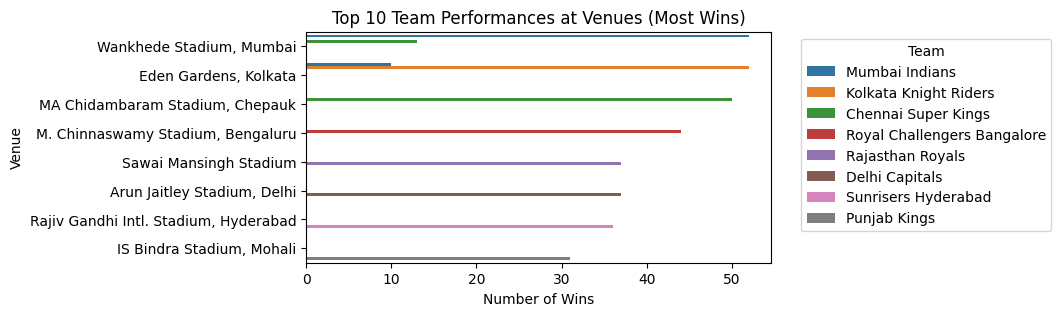

In [89]:
#Which Teams Perform Best at Each Venue
top_venue_team = matches.groupby(['venue', 'winner']).size().reset_index(name='wins')
top_venue_team = top_venue_team.sort_values(by='wins', ascending=False).head(10)

# Plot
plt.figure(figsize=(6,3))
sns.barplot(data=top_venue_team, x='wins', y='venue', hue='winner')
plt.title('Top 10 Team Performances at Venues (Most Wins)')
plt.xlabel('Number of Wins')
plt.ylabel('Venue')
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

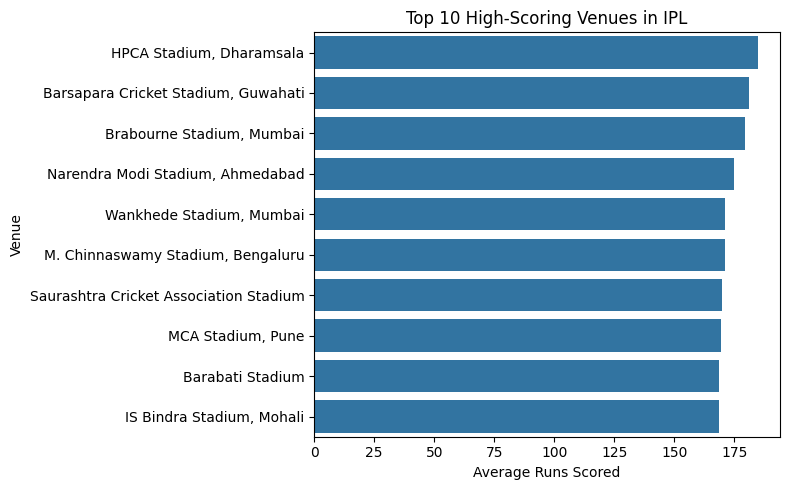

In [90]:
# high-scoring venues
top_scoring_venues = matches.groupby(['city','venue'])['target_runs'].mean().reset_index(name='run_scored')
top_scoring_venues = top_scoring_venues.sort_values(by='run_scored', ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_scoring_venues, x='run_scored', y='venue')
plt.title('Top 10 High-Scoring Venues in IPL')
plt.xlabel('Average Runs Scored')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()


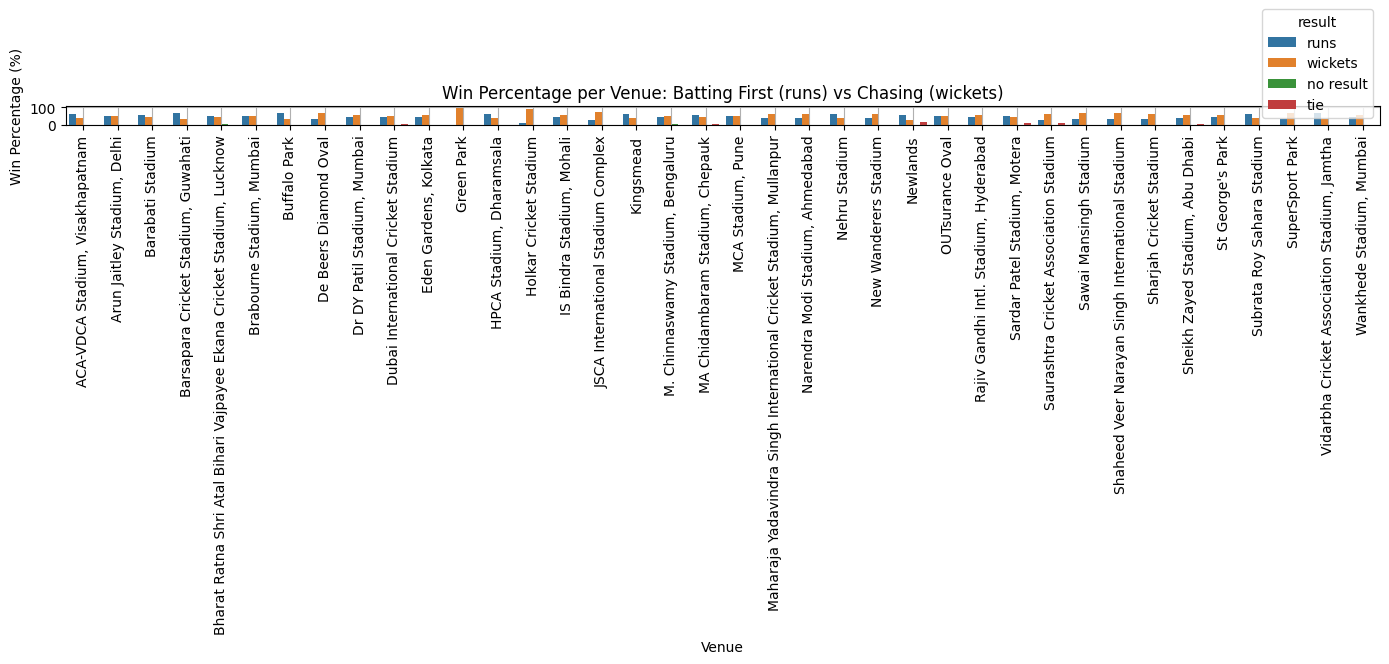

In [91]:
# Win percentage per venue — which stadium favors chasing/batting first?
venue_win = matches.groupby(['venue', 'result']).size().reset_index(name='Win_Count')
venue_win['venue_total_wins'] = venue_win.groupby('venue')['Win_Count'].transform('sum')
venue_win['Win_%'] = round((venue_win['Win_Count'] / venue_win['venue_total_wins']) * 100, 2)
venue_win = venue_win.sort_values(by=['venue', 'result'])

plt.figure(figsize=(14,6))
sns.barplot(data=venue_win, x='venue', y='Win_%', hue='result')
plt.xticks(rotation=90)
plt.title('Win Percentage per Venue: Batting First (runs) vs Chasing (wickets)')
plt.xlabel('Venue')
plt.ylabel('Win Percentage (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

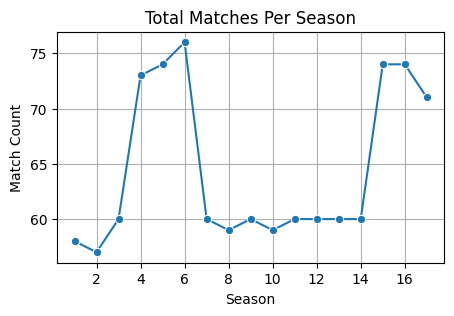

In [92]:
#matches per season
match_count=matches['season'].value_counts().sort_index()
plt.figure(figsize=(5,3))
sns.lineplot(x=match_count.index, y=match_count.values, marker='o')
plt.title("Total Matches Per Season")
plt.xlabel("Season")
plt.ylabel("Match Count")
plt.grid(True)
plt.show()

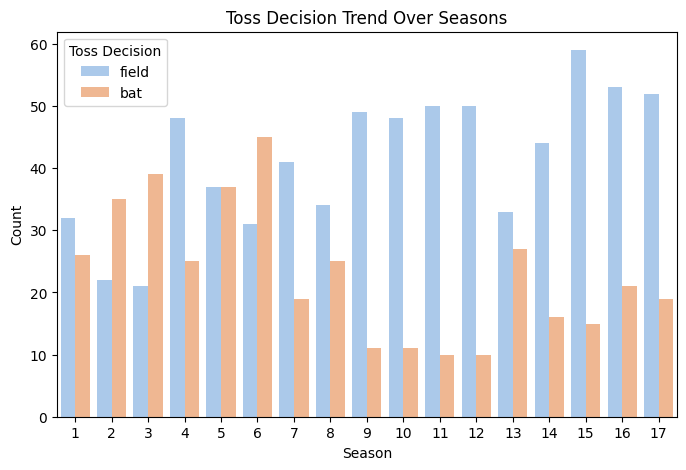

In [93]:
plt.figure(figsize=(8,5))
sns.countplot(data=matches, x='season', hue='toss_decision', palette='pastel')
plt.title('Toss Decision Trend Over Seasons')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Toss Decision')
plt.show()

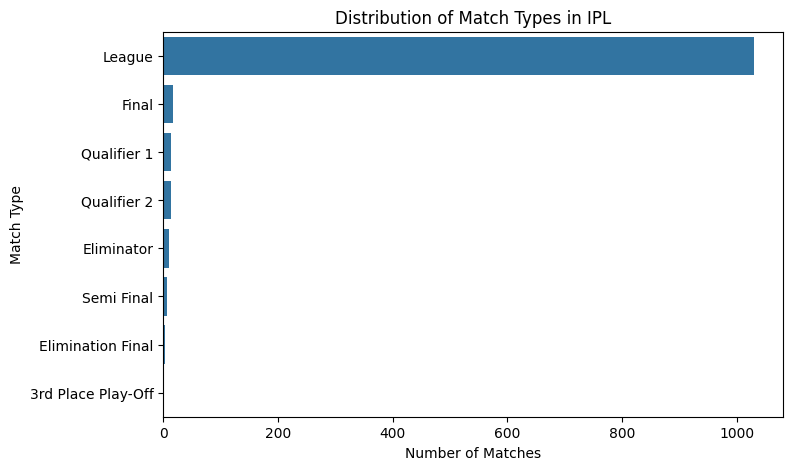

In [94]:
# Match type distribution
match_type_counts = matches['match_type'].value_counts().reset_index(name='match_played')
match_type_counts.columns = ['match_type', 'match_played']
plt.figure(figsize=(8, 5))
sns.barplot(data=match_type_counts, x='match_played', y='match_type')
plt.title('Distribution of Match Types in IPL')
plt.xlabel('Number of Matches')
plt.ylabel('Match Type')
plt.show()

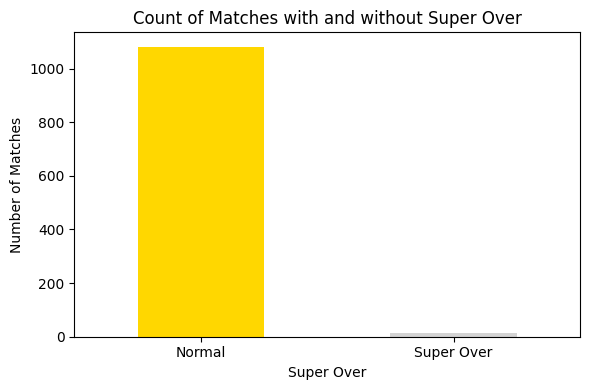

In [95]:
super_over_counts = matches['super_over'].value_counts()
super_over_counts.plot(kind='bar', color=['gold', 'lightgrey'], figsize=(6,4))
plt.title('Count of Matches with and without Super Over')
plt.xlabel('Super Over')
plt.ylabel('Number of Matches')
plt.xticks(ticks=[0,1], labels=['Normal', 'Super Over'], rotation=0)
plt.tight_layout()
plt.show()


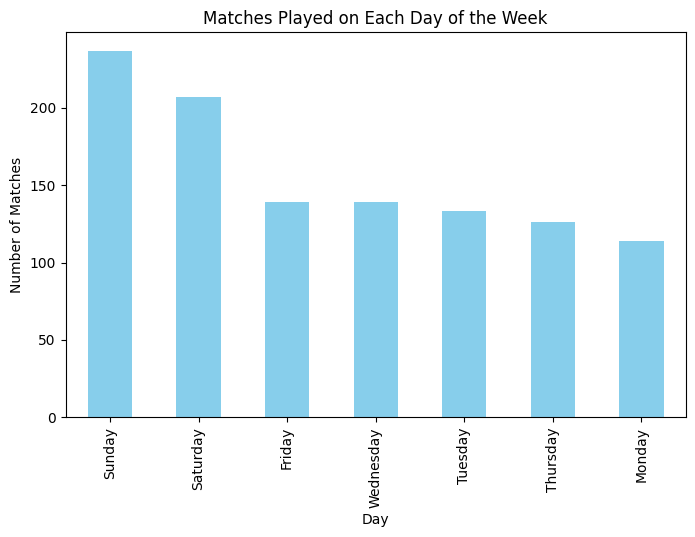

In [96]:
#no. of matches played on all diff days of week
day_counts = matches['match_day'].value_counts()

plt.figure(figsize=(8, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.title('Matches Played on Each Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Matches')
plt.show()

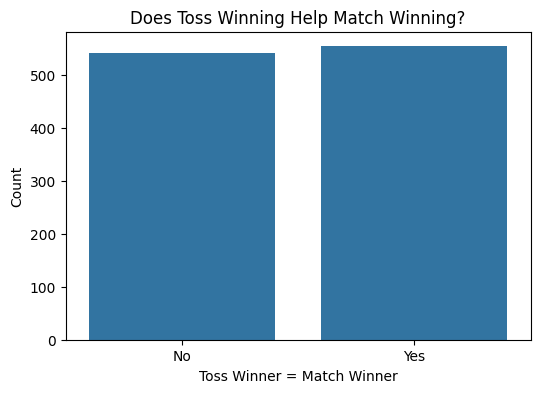

In [97]:
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']
plt.figure(figsize=(6,4))
sns.countplot(x='toss_match_win', data=matches)
plt.title("Does Toss Winning Help Match Winning?")
plt.xticks([0,1], ['No', 'Yes'])
plt.xlabel("Toss Winner = Match Winner")
plt.ylabel("Count")
plt.show()

Bat & Win: 177
Field & Win: 377


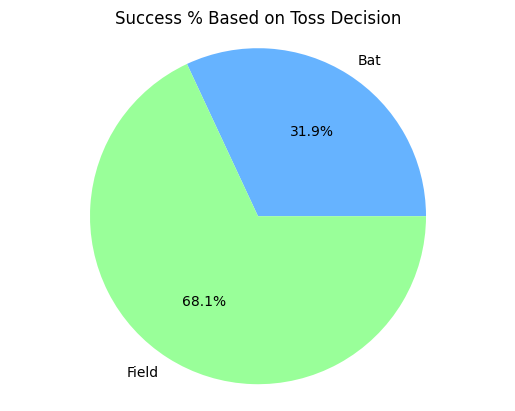

In [98]:
# 3.3•	Decision after toss: bat or field? Which is more successful?
df6 = matches[( matches['toss_decision'] == 'bat') & ( matches['toss_winner'] ==  matches['winner'])]
df7 =  matches[( matches['toss_decision'] == 'field') & ( matches['toss_winner'] ==  matches['winner'])]
print("Bat & Win:", len(df6))
print("Field & Win:", len(df7))
toss_success = pd.DataFrame({
    'Toss Decision': ['Bat', 'Field'],
    'Wins': [len(df6), len(df7)]
})
toss_success
plt.pie(toss_success['Wins'],
        labels=toss_success['Toss Decision'],
        autopct='%1.1f%%',
        colors=['#66b3ff', '#99ff99'])
plt.title("Success % Based on Toss Decision")
plt.axis('equal')
plt.show()


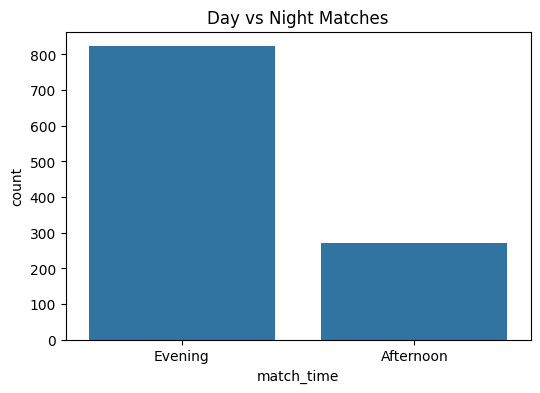

In [99]:
plt.figure(figsize=(6,4))
sns.countplot(x='match_time', data=matches)
plt.title("Day vs Night Matches")
plt.show()


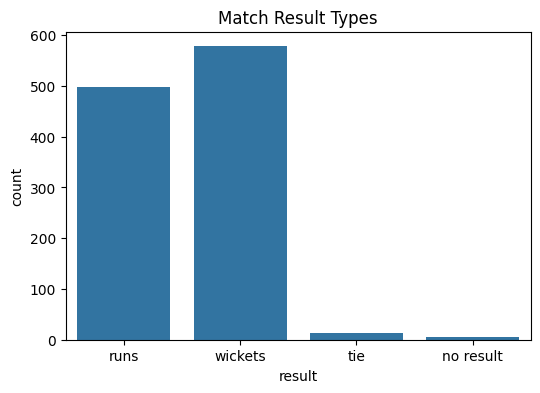

In [100]:
plt.figure(figsize=(6,4))
sns.countplot(x='result', data=matches)
plt.title("Match Result Types")
plt.show()


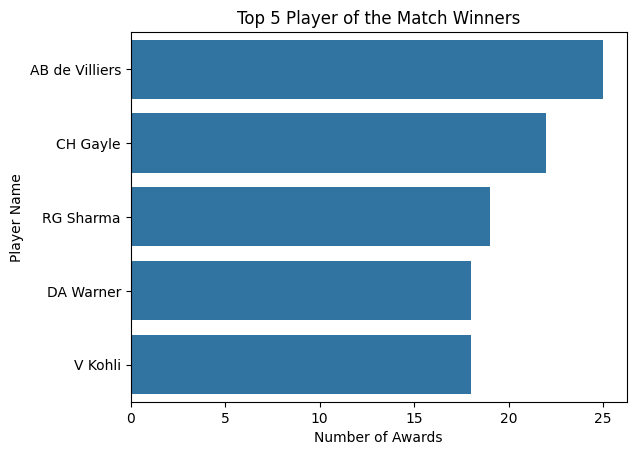

In [101]:
top_players = matches['player_of_match'].value_counts().head(5).reset_index()
top_players.columns = ['Player', 'Awards']

sns.barplot(data=top_players, x='Awards', y='Player')
plt.title('Top 5 Player of the Match Winners')
plt.xlabel('Number of Awards')
plt.ylabel('Player Name')
plt.show()

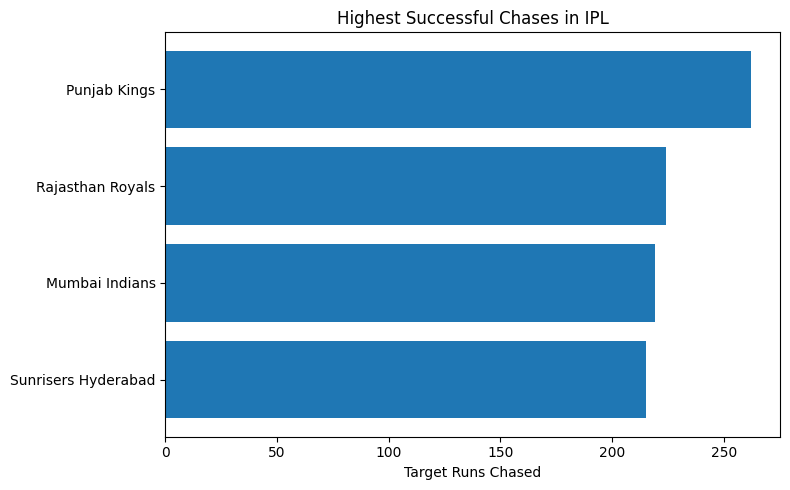

In [102]:
#Highest Successful Chases
top_chases = matches[matches['result'] == 'wickets'].sort_values(by='target_runs', ascending=False).head(5)

plt.figure(figsize=(8, 5))
plt.barh(top_chases['winner'], top_chases['target_runs'])
plt.xlabel('Target Runs Chased')
plt.title('Highest Successful Chases in IPL')
plt.gca().invert_yaxis()  # Highest chase at the top
plt.tight_layout()
plt.show()

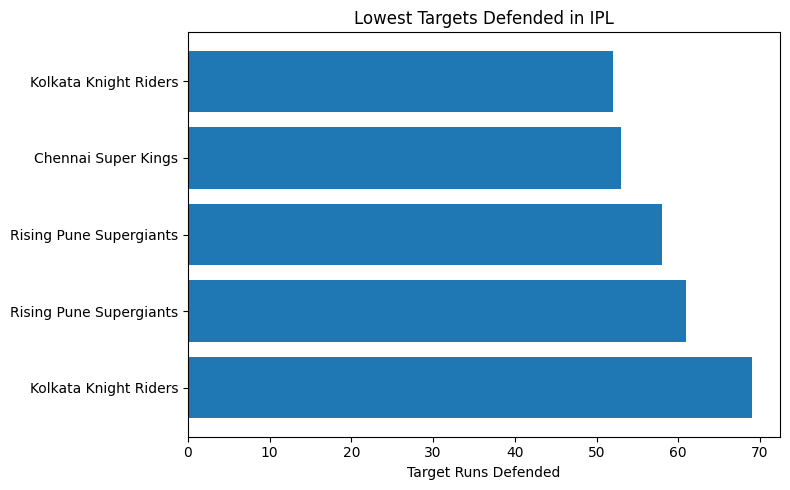

In [103]:
low_defends = matches[matches['result'] == 'runs'].sort_values(by='target_runs', ascending=True).head(5)

plt.figure(figsize=(8, 5))
plt.barh(range(5), low_defends['target_runs'])
plt.xlabel('Target Runs Defended')
plt.title('Lowest Targets Defended in IPL')
plt.gca().invert_yaxis()
plt.yticks(range(5),low_defends['winner'])
plt.tight_layout()
plt.show()

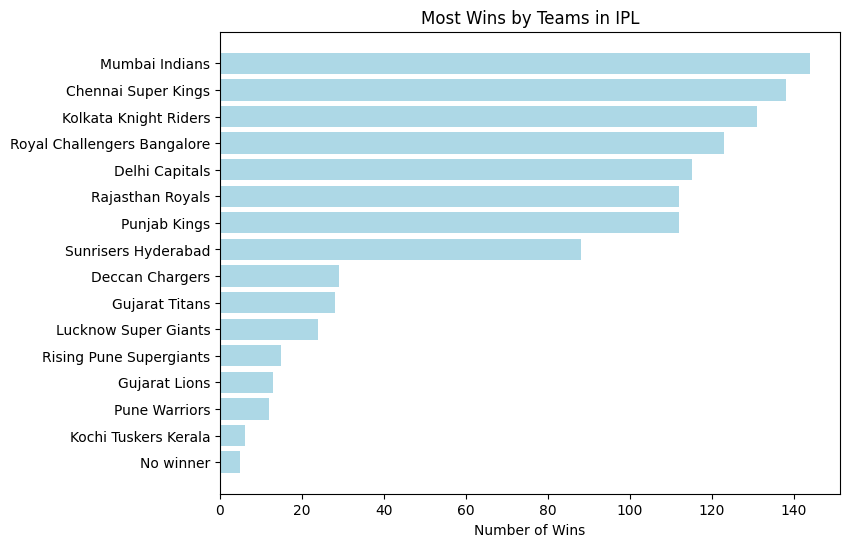

In [104]:
team_wins = matches['winner'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']
plt.figure(figsize=(8, 6))
plt.barh(team_wins['team'], team_wins['wins'], color='lightblue')
plt.xlabel('Number of Wins')
plt.title('Most Wins by Teams in IPL')
plt.gca().invert_yaxis() 

plt.show()

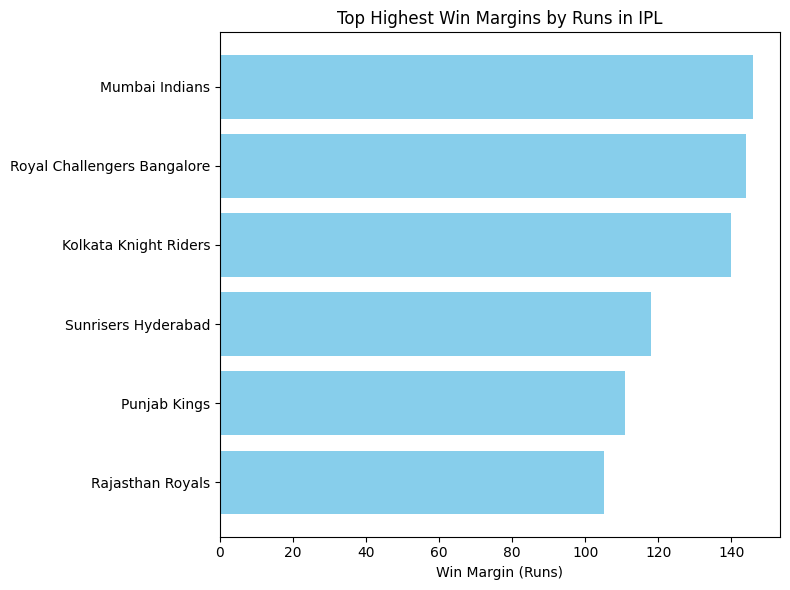

In [105]:
top_win_by_runs = matches[matches['result'] == 'runs'].sort_values(by='win_by', ascending=False).head(10)
top_win_by_runs = top_win_by_runs[['team1', 'team2', 'winner', 'win_by']]
plt.figure(figsize=(8, 6))
plt.barh(top_win_by_runs['winner'], top_win_by_runs['win_by'], color='skyblue')
plt.xlabel('Win Margin (Runs)')
plt.title('Top Highest Win Margins by Runs in IPL')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

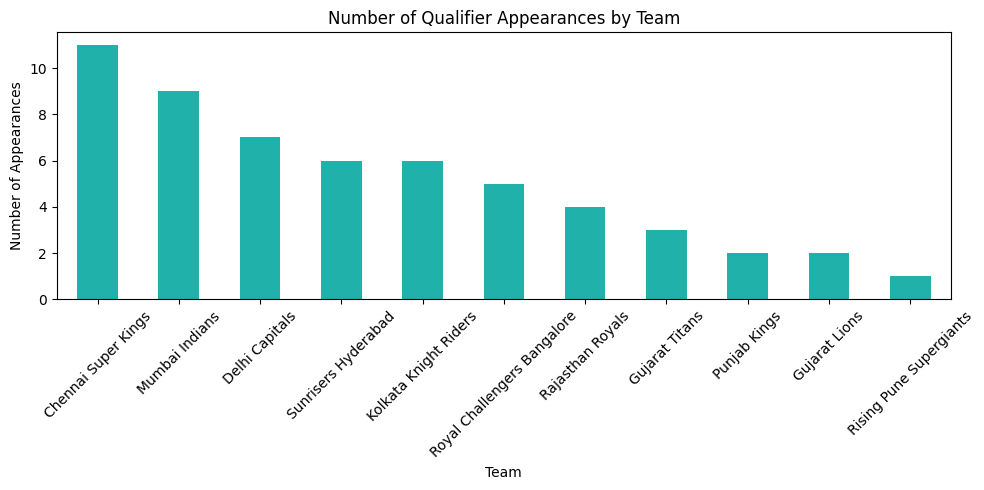

In [106]:
qualifier_matches = matches[matches['match_type'].isin(['Qualifier 1', 'Qualifier 2'])]
qualifier_teams = pd.concat([qualifier_matches['team1'], qualifier_matches['team2']])
qualification_counts = qualifier_teams.value_counts()

# Plotting
qualification_counts.plot(kind='bar', color='lightseagreen', figsize=(10,5))
plt.title('Number of Qualifier Appearances by Team')
plt.xlabel('Team')
plt.ylabel('Number of Appearances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

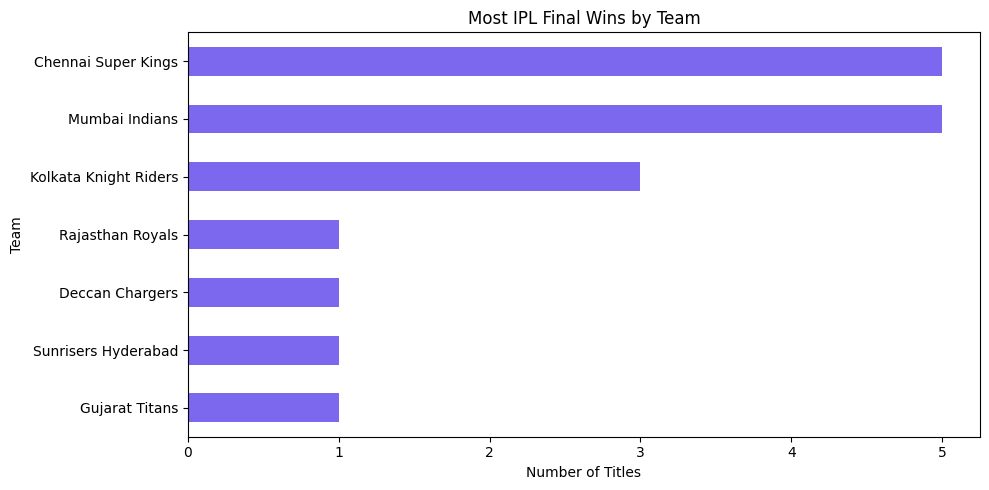

In [107]:
final_wins = matches[matches['match_type'] == 'Final']['winner'].value_counts()


final_wins.plot(kind='barh', color='mediumslateblue', figsize=(10, 5))
plt.title('Most IPL Final Wins by Team')
plt.xlabel('Number of Titles')
plt.ylabel('Team')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

#### MACHINE LEARNING

In [202]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [206]:
label_encoders = {}

for column in matches.columns:
    
    le = LabelEncoder()
    
    matches[column] = matches[column].astype(str)
    
    matches[column] = le.fit_transform(matches[column])
    
    label_encoders[column] = le

In [208]:
X = matches.drop('winner', axis=1)
y = matches['winner']

In [210]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [212]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [214]:
y_pred = model.predict(X_test)

In [216]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.6484018264840182


In [218]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.93      0.76        27
           1       0.67      0.67      0.67         3
           2       0.00      0.00      0.00         2
           3       0.59      0.50      0.54        26
           4       0.85      0.68      0.76        25
           5       1.00      0.33      0.50         3
           6       0.67      0.61      0.63        33
           7       0.50      0.64      0.56        11
           8       0.65      0.55      0.59        20
           9       1.00      0.33      0.50         6
          10       0.80      0.67      0.73         6
          11       0.00      0.00      0.00         2
          12       0.66      0.75      0.70        28
          13       1.00      0.50      0.67         6
          14       0.50      0.75      0.60        20
          15       1.00      1.00      1.00         1

    accuracy                           0.65       219
   macro avg       0.66   

In [222]:
importance = model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, ":", score)

year : 0.04716378513706995
city : 0.05855647588495606
date : 0.07043433266001785
match_type : 0.005143671507666278
player_of_match : 0.08547789849207345
venue : 0.07216692322399793
team1 : 0.10651273468626245
team2 : 0.11594052836564123
toss_winner : 0.11191729562780245
toss_decision : 0.016278638207967926
result : 0.0295497516554765
win_by : 0.05981391739180058
target_runs : 0.0650819235071703
target_overs : 0.003845831453372237
super_over : 0.0008351440707341631
method : 0.003512388537875028
season : 0.045497645696214374
match_time : 0.014195098170398318
match_day : 0.04332440211670139
toss_match_win : 0.04475161360680141


In [226]:
#Save Model
import joblib
joblib.dump(model, "ipl_model.pkl")
joblib.dump(label_encoders, "encoders.pkl")

print("Model Saved")

Model Saved


In [ ]:
python model.py

In [232]:
import streamlit as st

model = joblib.load("ipl_model.pkl")

label_encoders = joblib.load("encoders.pkl")

st.title("IPL Match Winner Prediction")


teams = list(label_encoders['team1'].classes_)

venues = list(label_encoders['venue'].classes_)

cities = list(label_encoders['city'].classes_)


team1 = st.selectbox("Select Team 1", teams)

team2 = st.selectbox("Select Team 2", teams)

toss_winner = st.selectbox("Toss Winner", teams)

toss_decision = st.selectbox(
    "Toss Decision",
    ['bat', 'field']
)

venue = st.selectbox("Venue", venues)

city = st.selectbox("City", cities)

if st.button("Predict Winner"):

    input_data = pd.DataFrame({
        'team1': [team1],
        'team2': [team2],
        'toss_winner': [toss_winner],
        'toss_decision': [toss_decision],
        'venue': [venue],
        'city': [city]
    })

    # Encode Input

    for column in input_data.columns:

        input_data[column] = label_encoders[column].transform(
            input_data[column]
        )

    # Prediction

    prediction = model.predict(input_data)

    # Decode Result

    winner = label_encoders['winner'].inverse_transform(
        prediction
    )

    st.success(f"Predicted Winner : {winner[0]}")

2026-05-16 23:52:15.461 
  command:

    streamlit run C:\Users\Paras\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
